In [1]:
# --- Cell 1: Imports ---
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score)
from sklearn.metrics import confusion_matrix, accuracy_score
RANDOM_STATE = 55

from google.colab import drive
drive.mount('/content/drive')

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]
DATA_PATH   = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Dataset/scaled_dataset/'
FIG_PATH    = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/Figures/'

Mounted at /content/drive


In [2]:
# --- Cell 2: Load arrays ---
X_train = np.load(DATA_PATH + 'X_train_scaled.npy')
X_val   = np.load(DATA_PATH + 'X_val_scaled.npy')
X_test  = np.load(DATA_PATH + 'X_test_scaled.npy')
y_train = np.load(DATA_PATH + 'y_train_bal.npy')
y_val   = np.load(DATA_PATH + 'y_val.npy')
y_test  = np.load(DATA_PATH + 'y_test.npy')

print("Shapes loaded:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape},   y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape},  y_test:  {y_test.shape}")

Shapes loaded:
  X_train: (45728, 108), y_train: (45728,)
  X_val:   (27495, 108),   y_val:   (27495,)
  X_test:  (27495, 108),  y_test:  (27495,)


In [3]:
import joblib
!pip install xgboost
save_path   = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/models/'

xgb_model = joblib.load(save_path + 'xgb_model.pkl')
#print("XGBoost model loaded from Drive.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 13.5 MB/s eta 0:00:00


In [4]:
# ================================================================
#  KNN + PCA+KNN — Training and Validation only
# ================================================================
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)
import numpy as np
import time

CLASS_NAMES = ["Non-islanding", "Islanding", "Line Fault"]

def print_metrics(name, preds, y_true):
    non_mask  = y_true == 0
    isl_mask  = y_true == 1
    acc       = accuracy_score(y_true, preds) * 100
    prec_mac  = precision_score(y_true, preds, average='macro',
                                zero_division=0) * 100
    rec_mac   = recall_score(y_true, preds, average='macro',
                             zero_division=0) * 100
    f1_mac    = f1_score(y_true, preds, average='macro',
                         zero_division=0) * 100
    isl_prec  = precision_score(y_true, preds, labels=[1],
                                average='micro', zero_division=0) * 100
    isl_rec   = recall_score(y_true, preds, labels=[1],
                             average='micro', zero_division=0) * 100
    isl_f1    = f1_score(y_true, preds, labels=[1],
                         average='micro', zero_division=0) * 100
    fa        = ((preds == 1) & non_mask).sum()
    missed    = ((preds != 1) & isl_mask).sum()

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  {'Metric':<28} {'Value':>10}")
    print(f"  {'-'*40}")
    print(f"  {'Overall Accuracy':<28} {acc:>9.2f}%")
    print(f"  {'Macro Precision':<28} {prec_mac:>9.2f}%")
    print(f"  {'Macro Recall':<28} {rec_mac:>9.2f}%")
    print(f"  {'Macro F1':<28} {f1_mac:>9.2f}%")
    print(f"  {'-'*40}")
    print(f"  {'Islanding Precision':<28} {isl_prec:>9.2f}%")
    print(f"  {'Islanding Recall':<28} {isl_rec:>9.2f}%")
    print(f"  {'Islanding F1':<28} {isl_f1:>9.2f}%")
    print(f"  {'False Alarms':<28} {fa:>10,}")
    print(f"  {'Missed Islanding':<28} {missed:>10,}")
    return acc, isl_rec, isl_prec, isl_f1, f1_mac, fa, missed

# ================================================================
#  PART 1A — KNN on Original 108 Features
# ================================================================
print("=" * 60)
print("  KNN — Original Dataset (108 features)")
print("=" * 60)

k_values     = [3, 5, 7, 9, 11, 15]
knn_k_sweep  = []

print(f"\nK sweep on validation set...")
print(f"  {'K':>4} {'Train_Acc':>11} {'Val_Acc':>10} "
      f"{'Isl_Rec':>10} {'FA':>8} {'Time':>8}")
print(f"  {'-'*56}")

best_k_orig    = None
best_rec_orig  = -1
best_knn_orig  = None

for k in k_values:
    t0  = time.time()
    knn = KNeighborsClassifier(n_neighbors=k,
                                metric='euclidean',
                                n_jobs=-1)
    knn.fit(X_train, y_train)

    tr_preds  = knn.predict(X_train)
    val_preds = knn.predict(X_val)
    elapsed   = time.time() - t0

    tr_acc  = accuracy_score(y_train, tr_preds) * 100
    val_acc = accuracy_score(y_val, val_preds) * 100
    val_rec = recall_score(y_val, val_preds, labels=[1],
                           average='micro', zero_division=0) * 100
    val_fa  = ((val_preds == 1) & (y_val == 0)).sum()

    knn_k_sweep.append({
        'k': k, 'tr_acc': tr_acc, 'val_acc': val_acc,
        'val_rec': val_rec, 'val_fa': val_fa
    })

    marker = ' ← BEST' if val_rec > best_rec_orig else ''
    print(f"  {k:>4} {tr_acc:>10.2f}% {val_acc:>9.2f}% "
          f"{val_rec:>9.2f}% {val_fa:>8,} "
          f"{elapsed:>7.1f}s{marker}")

    if val_rec > best_rec_orig:
        best_rec_orig = val_rec
        best_k_orig   = k
        best_knn_orig = knn
        best_val_preds_orig = val_preds
        best_tr_preds_orig  = tr_preds

print(f"\n  → Best K = {best_k_orig}  "
      f"(val islanding recall = {best_rec_orig:.2f}%)")

# Full metrics for best K
print_metrics(f"KNN (K={best_k_orig}) — TRAINING SET",
              best_tr_preds_orig, y_train)
print_metrics(f"KNN (K={best_k_orig}) — VALIDATION SET",
              best_val_preds_orig, y_val)

# ================================================================
#  PART 1B — PCA + KNN
# ================================================================
print("\n" + "=" * 60)
print("  PCA + KNN — Dimensionality Reduction")
print("=" * 60)

variance_levels = [0.90, 0.95, 0.99]
pca_knn_results = {}

# Show PCA components
print(f"\nPCA component analysis:")
print(f"  {'Variance':>10} {'Components':>12} {'Explained':>12}")
print(f"  {'-'*36}")
for var in variance_levels:
    pca_temp  = PCA(n_components=var, random_state=42)
    pca_temp.fit(X_train)
    n_comp    = pca_temp.n_components_
    explained = pca_temp.explained_variance_ratio_.sum() * 100
    print(f"  {var:>10.0%} {n_comp:>12} {explained:>11.2f}%")

for var in variance_levels:
    print(f"\n── PCA {var:.0%} variance ──────────────────────────────")

    pca         = PCA(n_components=var, random_state=42)
    X_train_pca = pca.fit_transform(X_train)
    X_val_pca   = pca.transform(X_val)
    n_comp      = pca.n_components_
    print(f"  Reduced: 108 → {n_comp} features")

    print(f"\n  K sweep...")
    print(f"  {'K':>4} {'Train_Acc':>11} {'Val_Acc':>10} "
          f"{'Isl_Rec':>10} {'FA':>8} {'Time':>8}")
    print(f"  {'-'*56}")

    best_k_pca   = None
    best_rec_pca = -1
    best_knn_pca = None
    best_val_pca = None
    best_tr_pca  = None

    for k in k_values:
        t0      = time.time()
        knn_pca = KNeighborsClassifier(n_neighbors=k,
                                        metric='euclidean',
                                        n_jobs=-1)
        knn_pca.fit(X_train_pca, y_train)

        tr_preds  = knn_pca.predict(X_train_pca)
        val_preds = knn_pca.predict(X_val_pca)
        elapsed   = time.time() - t0

        tr_acc  = accuracy_score(y_train, tr_preds) * 100
        val_acc = accuracy_score(y_val, val_preds) * 100
        val_rec = recall_score(y_val, val_preds, labels=[1],
                               average='micro', zero_division=0) * 100
        val_fa  = ((val_preds == 1) & (y_val == 0)).sum()

        marker = ' ← BEST' if val_rec > best_rec_pca else ''
        print(f"  {k:>4} {tr_acc:>10.2f}% {val_acc:>9.2f}% "
              f"{val_rec:>9.2f}% {val_fa:>8,} "
              f"{elapsed:>7.1f}s{marker}")

        if val_rec > best_rec_pca:
            best_rec_pca = val_rec
            best_k_pca   = k
            best_knn_pca = knn_pca
            best_val_pca = val_preds
            best_tr_pca  = tr_preds
            best_pca_obj = pca

    print(f"\n  → Best K = {best_k_pca}  "
          f"(val islanding recall = {best_rec_pca:.2f}%)")

    print_metrics(f"KNN+PCA {var:.0%} (K={best_k_pca}) — TRAINING",
                  best_tr_pca, y_train)
    print_metrics(f"KNN+PCA {var:.0%} (K={best_k_pca}) — VALIDATION",
                  best_val_pca, y_val)

    pca_knn_results[var] = {
        'knn': best_knn_pca, 'pca': best_pca_obj,
        'k':   best_k_pca,   'val_rec': best_rec_pca,
    }

# ── Store best models for Part 2 ────────────────────────────────
print("\n" + "=" * 60)
print("  SUMMARY — Best K per model (validation islanding recall)")
print("=" * 60)
print(f"  KNN original:   K={best_k_orig}  "
      f"val_recall={best_rec_orig:.2f}%")
for var, res in pca_knn_results.items():
    print(f"  KNN+PCA {var:.0%}:   K={res['k']}  "
          f"val_recall={res['val_rec']:.2f}%")
print("\nReady for Part 2 — Test set evaluation.")

  KNN — Original Dataset (108 features)

K sweep on validation set...
     K   Train_Acc    Val_Acc    Isl_Rec       FA     Time
  --------------------------------------------------------
     3      97.91%     96.15%     93.73%      655     1.4s ← BEST
     5      97.55%     96.65%     93.22%      476     1.6s
     7      97.26%     96.72%     92.66%      409     1.6s
     9      97.01%     96.86%     92.23%      343     1.5s
    11      96.91%     96.90%     91.86%      306     1.3s
    15      96.67%     97.01%     91.47%      252     1.5s

  → Best K = 3  (val islanding recall = 93.73%)

  KNN (K=3) — TRAINING SET
  Metric                            Value
  ----------------------------------------
  Overall Accuracy                 97.91%
  Macro Precision                  98.14%
  Macro Recall                     98.12%
  Macro F1                         98.12%
  ----------------------------------------
  Islanding Precision              98.75%
  Islanding Recall                 9

Generating test predictions...
  KNN original done in 0.5s
  KNN+PCA 90% done in 0.3s
  KNN+PCA 95% done in 0.3s
  KNN+PCA 99% done in 0.4s

  KNN (K=3) ─ TEST SET
               precision    recall  f1-score   support

Non-islanding     0.9808    0.9636    0.9721     17959
    Islanding     0.8936    0.9410    0.9167      5712
   Line Fault     0.9940    0.9969    0.9954      3824

     accuracy                         0.9636     27495
    macro avg     0.9561    0.9672    0.9614     27495
 weighted avg     0.9645    0.9636    0.9639     27495



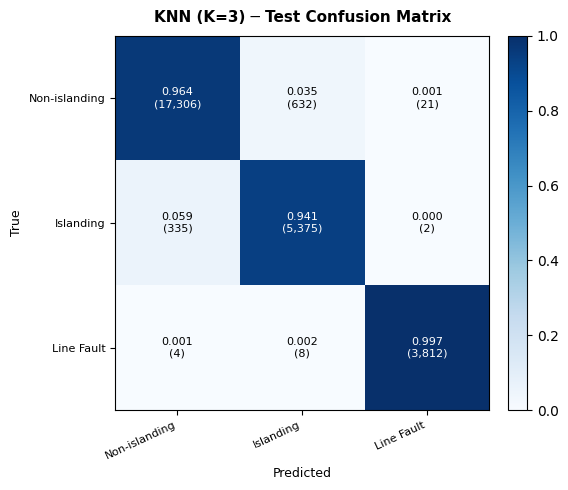


  KNN+PCA 90% (K=3) ─ TEST SET
               precision    recall  f1-score   support

Non-islanding     0.9790    0.9582    0.9685     17959
    Islanding     0.8742    0.9357    0.9039      5712
   Line Fault     0.9940    0.9885    0.9912      3824

     accuracy                         0.9578     27495
    macro avg     0.9491    0.9608    0.9546     27495
 weighted avg     0.9593    0.9578    0.9583     27495



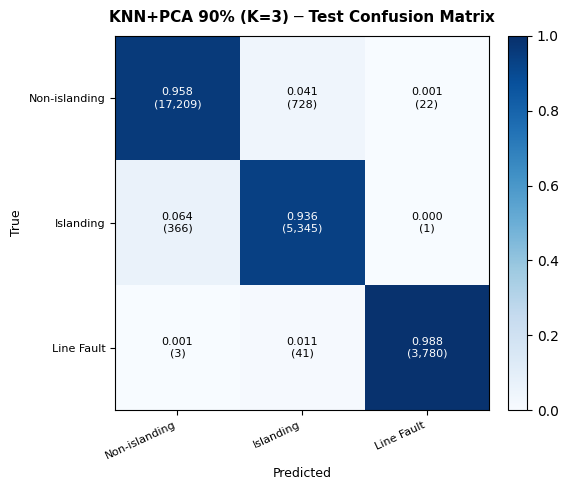


  KNN+PCA 95% (K=3) ─ TEST SET
               precision    recall  f1-score   support

Non-islanding     0.9798    0.9599    0.9698     17959
    Islanding     0.8820    0.9382    0.9092      5712
   Line Fault     0.9935    0.9937    0.9936      3824

     accuracy                         0.9601     27495
    macro avg     0.9518    0.9639    0.9575     27495
 weighted avg     0.9614    0.9601    0.9605     27495



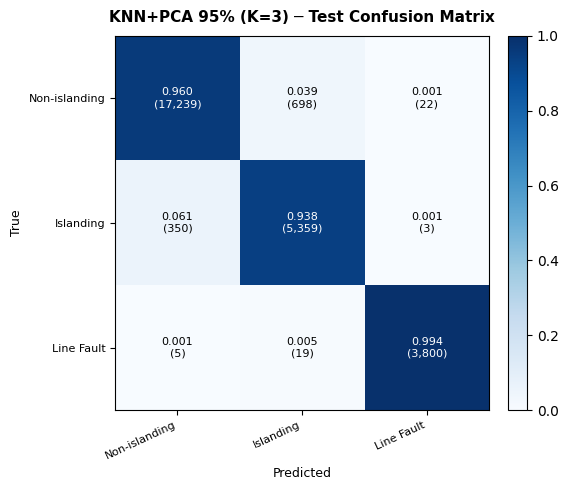


  KNN+PCA 99% (K=3) ─ TEST SET
               precision    recall  f1-score   support

Non-islanding     0.9804    0.9622    0.9713     17959
    Islanding     0.8884    0.9396    0.9133      5712
   Line Fault     0.9937    0.9948    0.9942      3824

     accuracy                         0.9621     27495
    macro avg     0.9542    0.9655    0.9596     27495
 weighted avg     0.9632    0.9621    0.9624     27495



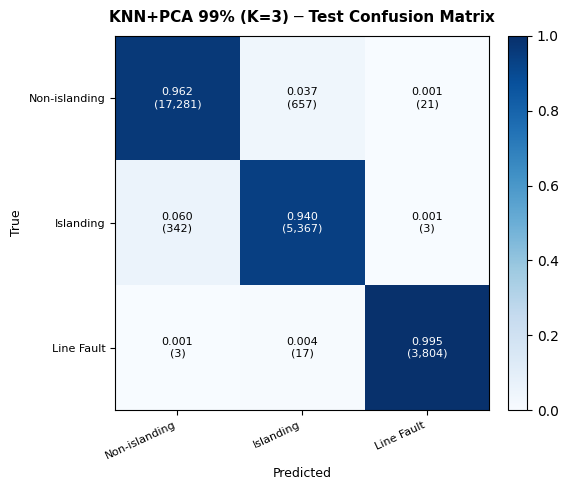


  FULL MODEL COMPARISON ─ TEST SET
  Model                            Accuracy   Isl_Rec    Isl_F1   MacroF1       FA   Missed
  ------------------------------------------------------------------------------
  MLP                            (not found)
  SVM Poly d=5 C=10                  97.84%    91.58%    94.66%    97.66%      107      481
  XGBoost argmax                     97.53%    96.06%    94.19%    97.42%      452      225
  XGBoost thresh=0.45                97.30%    96.48%    93.71%    97.20%      539      201 ★
  RF argmax                          98.35%    94.75%    95.97%    98.24%      154      300
  RF thresh=0.45                     98.09%    95.52%    95.40%    97.98%      270      256
  KNN (K=3)                          96.36%    94.10%    91.67%    96.14%      632      337
  KNN+PCA 90% (K=3)                  95.78%    93.57%    90.39%    95.46%      728      367
  KNN+PCA 95% (K=3)                  96.01%    93.82%    90.92%    95.75%      698      353
  KNN+PC

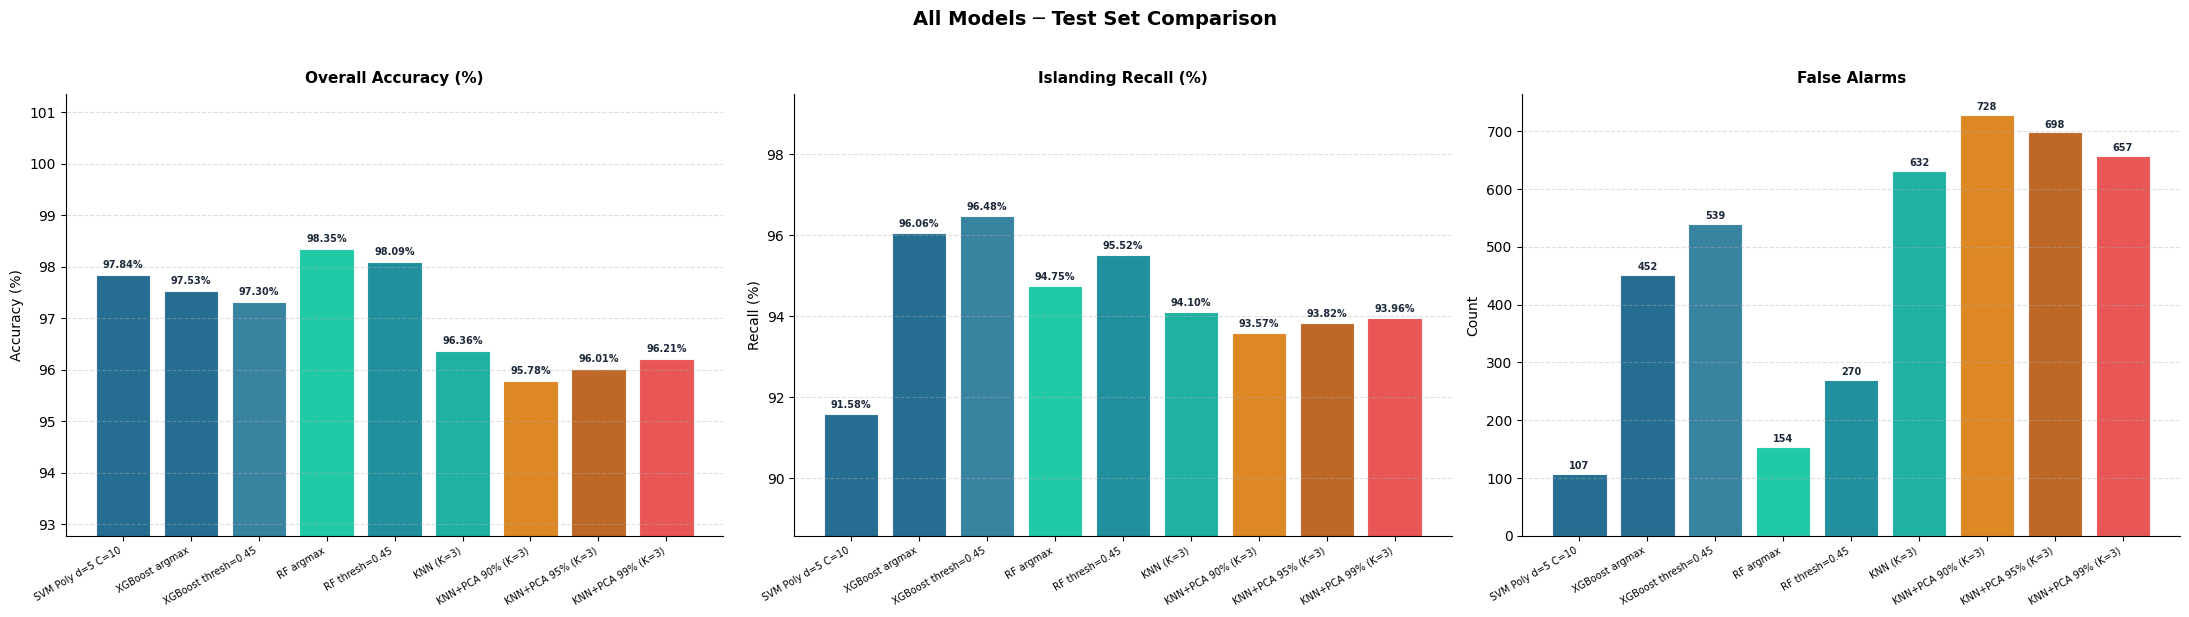

Full comparison plot saved.


In [5]:
# ================================================================
#  KNN + PCA+KNN — Test Set Evaluation & Full Comparison
# ================================================================
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score)
save_path='/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/'

def plot_cm(preds, y_true, title, save_name):
    cm      = confusion_matrix(y_true, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)
    ax.set_xticks([0,1,2]); ax.set_yticks([0,1,2])
    ax.set_xticklabels(CLASS_NAMES, rotation=25,
                       ha='right', fontsize=8)
    ax.set_yticklabels(CLASS_NAMES, fontsize=8)
    for i in range(3):
        for j in range(3):
            ax.text(j, i,
                    f"{cm_norm[i,j]:.3f}\n({cm[i,j]:,})",
                    ha='center', va='center', fontsize=8,
                    color='white' if cm_norm[i,j] > 0.5
                    else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(save_path + f'Figures/{save_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

# ── Test predictions ──────────────────────────────
print("Generating test predictions...")

t0 = time.time()
test_preds_knn = best_knn_orig.predict(X_test)
print(f"  KNN original done in {time.time()-t0:.1f}s")

pca_test_preds = {}
for var, res in pca_knn_results.items():
    X_test_pca = res['pca'].transform(X_test)
    t0 = time.time()
    pca_test_preds[var] = res['knn'].predict(X_test_pca)
    print(f"  KNN+PCA {var:.0%} done in {time.time()-t0:.1f}s")

# ── Classification reports ───────────────────────────────
print(f"\n{'='*60}")
print(f"  KNN (K={best_k_orig}) ─ TEST SET")
print(f"{'='*60}")
print(classification_report(y_test, test_preds_knn,
                            target_names=CLASS_NAMES, digits=4))
plot_cm(test_preds_knn, y_test,
        f'KNN (K={best_k_orig}) ─ Test Confusion Matrix',
        'knn_original_confusion_matrix')

for var, preds in pca_test_preds.items():
    k = pca_knn_results[var]['k']
    print(f"\n{'='*60}")
    print(f"  KNN+PCA {var:.0%} (K={k}) ─ TEST SET")
    print(f"{'='*60}")
    print(classification_report(y_test, preds,
                                target_names=CLASS_NAMES, digits=4))
    plot_cm(preds, y_test,
            f'KNN+PCA {var:.0%} (K={k}) ─ Test Confusion Matrix',
            f'knn_pca_{int(var*100)}_confusion_matrix')

# ── Save predictions ──────────────────────────────
np.save(save_path + 'knn_test_preds.npy', test_preds_knn)
for var, preds in pca_test_preds.items():
    np.save(save_path + f'knn_pca_{int(var*100)}_test_preds.npy',
            preds)

# ── Full comparison table ─ all algorithms ───────────────────────
print(f"\n{'='*80}")
print(f"  FULL MODEL COMPARISON ─ TEST SET")
print(f"{'='*80}")
print(f"  {'Model':<30} {'Accuracy':>10} {'Isl_Rec':>9} "
      f"{'Isl_F1':>9} {'MacroF1':>9} {'FA':>8} {'Missed':>8}")
print(f"  {'-'*78}")

# Load all saved predictions
all_models = {
    'MLP':                  np.load(save_path + 'mlp_test_preds.npy')
                            if __import__('os').path.exists(
                            save_path + 'mlp_test_preds.npy')
                            else None,
    'SVM Poly d=5 C=10':   np.load(save_path + 'svm_test_preds.npy'),
    'XGBoost argmax':       np.argmax(
                            xgb_model.predict_proba(X_test),
                            axis=1),
    'XGBoost thresh=0.45':  np.where(
                            xgb_model.predict_proba(
                            X_test)[:, 1] >= 0.45, 1,
                            np.where(
                            xgb_model.predict_proba(
                            X_test)[:, 0] >=
                            xgb_model.predict_proba(
                            X_test)[:, 2], 0, 2)),
    'RF argmax':            np.load(save_path + 'rf_test_preds.npy'),
    'RF thresh=0.45':       np.load(save_path +
                            'rf_thresh_test_preds.npy'),
    f'KNN (K={best_k_orig})':
                            test_preds_knn,
}

for var, preds in pca_test_preds.items():
    k = pca_knn_results[var]['k']
    all_models[f'KNN+PCA {var:.0%} (K={k})'] = preds

for model_name, preds in all_models.items():
    if preds is None:
        print(f"  {model_name:<30} {'(not found)':>10}")
        continue

    acc     = accuracy_score(y_test, preds) * 100
    isl_rec = recall_score(y_test, preds, labels=[1],
                           average='micro', zero_division=0) * 100
    isl_f1  = f1_score(y_test, preds, labels=[1],
                       average='micro', zero_division=0) * 100
    mac_f1  = f1_score(y_test, preds, average='macro',
                       zero_division=0) * 100
    fa      = ((preds == 1) & (y_test == 0)).sum()
    missed  = ((preds != 1) & (y_test == 1)).sum()

    # Highlight best model
    marker  = ' ★' if isl_rec == max(
        recall_score(y_test, p, labels=[1], average='micro',
                     zero_division=0) * 100
        for p in all_models.values() if p is not None) else ''

    print(f"  {model_name:<30} {acc:>9.2f}% {isl_rec:>8.2f}% "
          f"{isl_f1:>8.2f}% {mac_f1:>8.2f}% "
          f"{fa:>8,} {missed:>8,}{marker}")

# ── Comparison bar chart ────────────────────────────────
model_labels = []
acc_vals     = []
rec_vals     = []
fa_vals      = []

for model_name, preds in all_models.items():
    if preds is None:
        continue
    model_labels.append(model_name)
    acc_vals.append(accuracy_score(y_test, preds) * 100)
    rec_vals.append(recall_score(y_test, preds, labels=[1],
                                 average='micro',
                                 zero_division=0) * 100)
    fa_vals.append(((preds == 1) & (y_test == 0)).sum())

x       = np.arange(len(model_labels))
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('All Models ─ Test Set Comparison',
             fontsize=14, fontweight='bold', y=1.02)

PALETTE = ['#065A82', '#065A82', '#1C7293', '#02C39A',
           '#028090', '#00A896', '#D97706', '#B45309',
           '#E53E3E', '#C53030']

for ax, vals, title, ylabel in [
    (axes[0], acc_vals, 'Overall Accuracy (%)', 'Accuracy (%)'),
    (axes[1], rec_vals, 'Islanding Recall (%)', 'Recall (%)'),
    (axes[2], fa_vals,  'False Alarms',          'Count'),
]:
    colors = PALETTE[:len(model_labels)]
    bars   = ax.bar(x, vals, color=colors,
                    alpha=0.88, edgecolor='white', linewidth=0.8)

    for bar, val in zip(bars, vals):
        label = f'{val:.2f}%' if ylabel != 'Count' else f'{val:,}'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.1 if ylabel != 'Count'
                                    else 5),
                label, ha='center', va='bottom',
                fontsize=7, fontweight='bold', color='#1E293B',
                rotation=0)

    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=7,
                       rotation=30, ha='right')
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    if ylabel != 'Count':
        ax.set_ylim([min(vals) - 3, max(vals) + 3])

plt.tight_layout()
plt.savefig(save_path + 'Figures/all_models_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Full comparison plot saved.")

LIghtboostgm

In [6]:
lgb_test_preds  = np.load(save_path + 'lgb_test_preds.npy')
thresh_test     = np.load(save_path + 'lgb_thresh_test_preds.npy')
best_thresh = 0.45


  CLASSIFICATION REPORTS — TEST SET

  XGBoost argmax — TEST SET
               precision    recall  f1-score   support

Non-islanding     0.9874    0.9748    0.9810     17959
    Islanding     0.9239    0.9606    0.9419      5712
   Line Fault     0.9995    1.0000    0.9997      3824

     accuracy                         0.9753     27495
    macro avg     0.9702    0.9785    0.9742     27495
 weighted avg     0.9759    0.9753    0.9755     27495


  XGBoost thresh=0.45 — TEST SET
               precision    recall  f1-score   support

Non-islanding     0.9886    0.9699    0.9792     17959
    Islanding     0.9109    0.9648    0.9371      5712
   Line Fault     0.9995    1.0000    0.9997      3824

     accuracy                         0.9730     27495
    macro avg     0.9663    0.9782    0.9720     27495
 weighted avg     0.9740    0.9730    0.9733     27495


  RF argmax — TEST SET
               precision    recall  f1-score   support

Non-islanding     0.9834    0.9914    0.9874

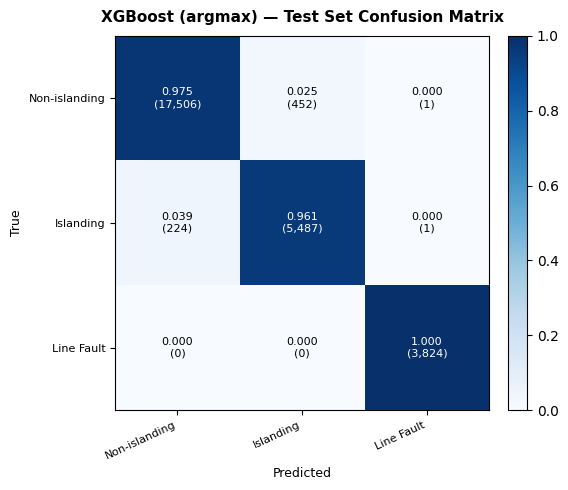

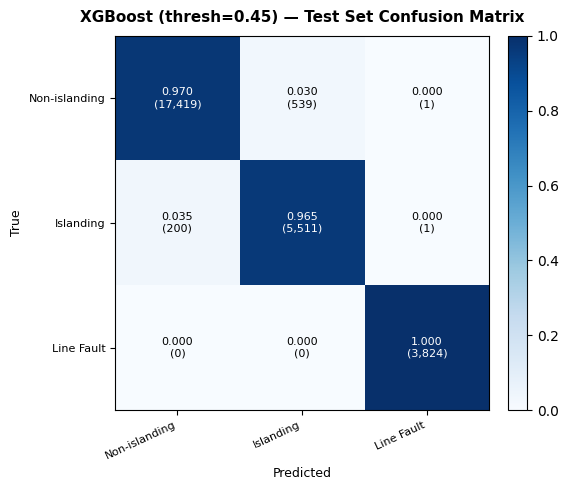

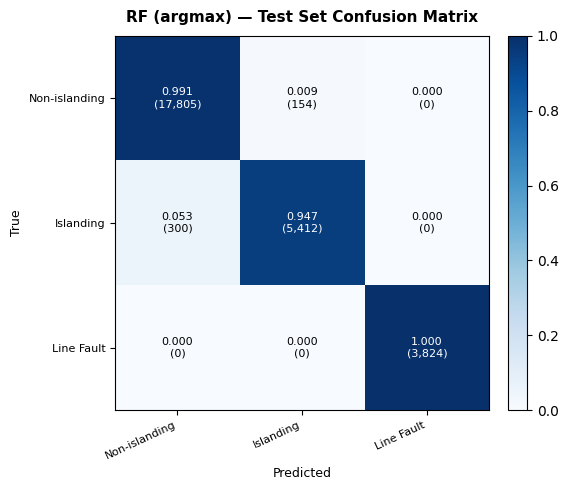

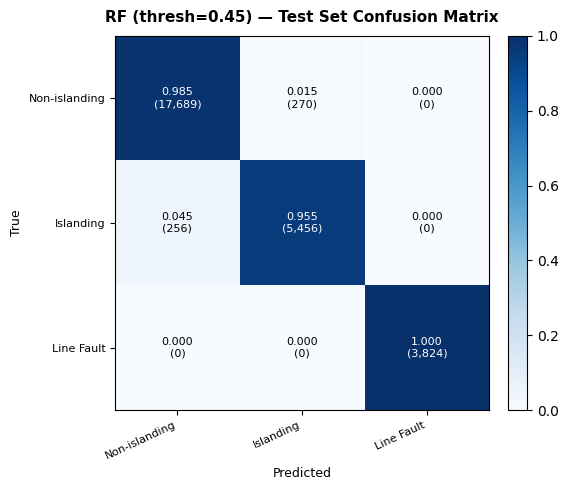

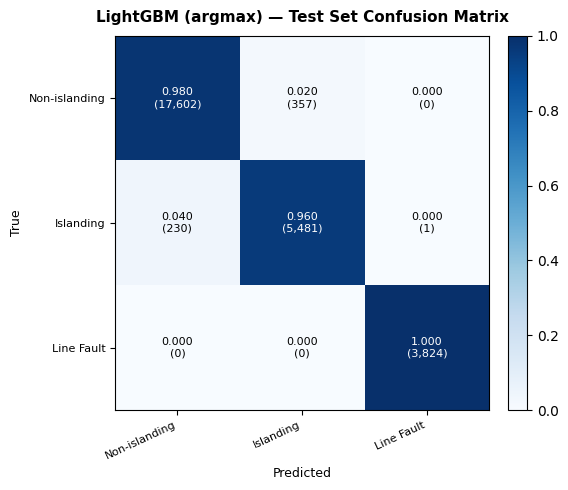

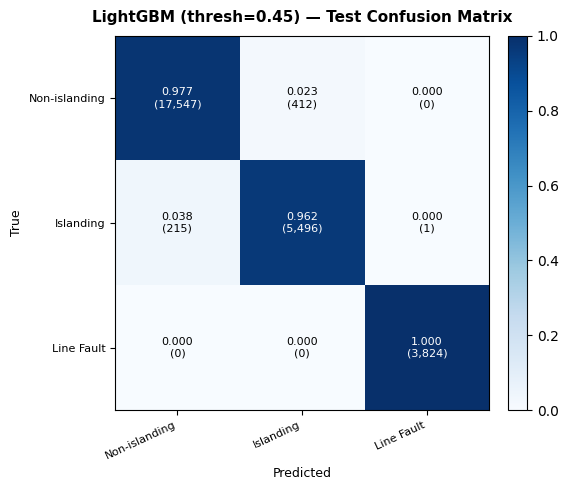


  SUMMARY — XGBoost vs RF vs LightGBM — TEST SET
  Model                               Acc   Isl_Rec   Isl_Pre    Isl_F1   MacroF1       FA   Missed
  ----------------------------------------------------------------------------------
  XGBoost argmax                   97.53%    96.06%    92.39%    94.19%    97.42%      452      225
  XGBoost thresh=0.45              97.30%    96.48%    91.09%    93.71%    97.20%      539      201 ★
  RF argmax                        98.35%    94.75%    97.23%    95.97%    98.24%      154      300
  RF thresh=0.45                   98.09%    95.52%    95.28%    95.40%    97.98%      270      256
  LightGBM argmax                  97.86%    95.96%    93.88%    94.91%    97.75%      357      231
  LightGBM thresh=0.45             97.72%    96.22%    93.03%    94.60%    97.61%      412      216


In [7]:
# ================================================================
#  STAGE 6 — Classification reports and summary table
#            XGBoost, LightGBM, RF and RF+Adaptive Threshold
# ================================================================
xgb_test_preds    = np.load(save_path + 'xgb_test_preds.npy')
xgb_thresh_preds  = np.load(save_path + 'xgb_thresh_test_preds.npy')
rf_test_preds     = np.load(save_path + 'rf_test_preds.npy')
rf_thresh_preds   = np.load(save_path + 'rf_thresh_test_preds.npy')

# ── Classification reports for all models ────────────────────────
print(f"\n{'='*62}")
print(f"  CLASSIFICATION REPORTS — TEST SET")
print(f"{'='*62}")

report_models = {
    'XGBoost argmax':                      xgb_test_preds,
    'XGBoost thresh=0.45':                 xgb_thresh_preds,
    'RF argmax':                           rf_test_preds,
    'RF thresh=0.45':                      rf_thresh_preds,
    'LightGBM argmax':                     lgb_test_preds,
    f'LightGBM thresh={best_thresh:.2f}':  thresh_test,
}

for name, preds in report_models.items():
    print(f"\n{'='*62}")
    print(f"  {name} — TEST SET")
    print(f"{'='*62}")
    print(classification_report(y_test, preds,
                                target_names=CLASS_NAMES, digits=4))

# ── Confusion matrices for all models ────────────────────────────
plot_cm(xgb_test_preds, y_test,
        'XGBoost (argmax) — Test Set Confusion Matrix',
        'xgb_confusion_matrix')
plot_cm(xgb_thresh_preds, y_test,
        'XGBoost (thresh=0.45) — Test Set Confusion Matrix',
        'xgb_thresh_confusion_matrix')
plot_cm(rf_test_preds, y_test,
        'RF (argmax) — Test Set Confusion Matrix',
        'rf_argmax_confusion_matrix')
plot_cm(rf_thresh_preds, y_test,
        'RF (thresh=0.45) — Test Set Confusion Matrix',
        'rf_thresh_confusion_matrix')
plot_cm(lgb_test_preds, y_test,
        'LightGBM (argmax) — Test Set Confusion Matrix',
        'lgb_confusion_matrix')
plot_cm(thresh_test, y_test,
        f'LightGBM (thresh={best_thresh:.2f}) — Test Confusion Matrix',
        'lgb_thresh_confusion_matrix')

# ── Summary comparison table ─────────────────────────────────────
print(f"\n{'='*80}")
print(f"  SUMMARY — XGBoost vs RF vs LightGBM — TEST SET")
print(f"{'='*80}")
print(f"  {'Model':<30} {'Acc':>8} {'Isl_Rec':>9} "
      f"{'Isl_Pre':>9} {'Isl_F1':>9} {'MacroF1':>9} "
      f"{'FA':>8} {'Missed':>8}")
print(f"  {'-'*82}")

best_rec = max(
    recall_score(y_test, p, labels=[1],
                 average='micro', zero_division=0)
    for p in report_models.values()
)

for name, preds in report_models.items():
    acc    = accuracy_score(y_test, preds) * 100
    rec    = recall_score(y_test, preds, labels=[1],
                          average='micro', zero_division=0) * 100
    pre    = precision_score(y_test, preds, labels=[1],
                             average='micro', zero_division=0) * 100
    f1     = f1_score(y_test, preds, labels=[1],
                      average='micro', zero_division=0) * 100
    mac_f1 = f1_score(y_test, preds, average='macro',
                      zero_division=0) * 100
    fa     = ((preds == 1) & (y_test == 0)).sum()
    mis    = ((preds != 1) & (y_test == 1)).sum()
    star   = ' ★' if rec == best_rec * 100 else ''
    print(f"  {name:<30} {acc:>7.2f}% {rec:>8.2f}% "
          f"{pre:>8.2f}% {f1:>8.2f}% {mac_f1:>8.2f}% "
          f"{fa:>8,} {mis:>8,}{star}")

In [8]:
import os

save_path = '/content/drive/MyDrive/Final Year Project/Islanding_project/Dataset/Islanding-Detection-in-Colab/Outputs/'

# List all .npy files in Outputs
print("Files in Outputs folder:")
for f in sorted(os.listdir(save_path)):
    if f.endswith('.npy'):
        print(f"  {f}")

Files in Outputs folder:
  knn_pca_90_test_preds.npy
  knn_pca_95_test_preds.npy
  knn_pca_99_test_preds.npy
  knn_test_preds.npy
  lgb_test_preds.npy
  lgb_thresh_test_preds.npy
  rf_nb_test_preds.npy
  rf_qda_test_preds.npy
  rf_test_preds.npy
  rf_thresh_test_preds.npy
  rf_train_preds.npy
  rf_val_preds.npy
  svm_test_preds.npy
  xgb_test_preds.npy
  xgb_thresh_test_preds.npy


Verification — Islanding Recall (test):
  XGBoost                96.06%   XGBoost + T=0.45          96.48%
  RF                     94.75%   RF + T=0.45               95.52%
  LightGBM               95.96%   LightGBM + T=0.45         96.22%


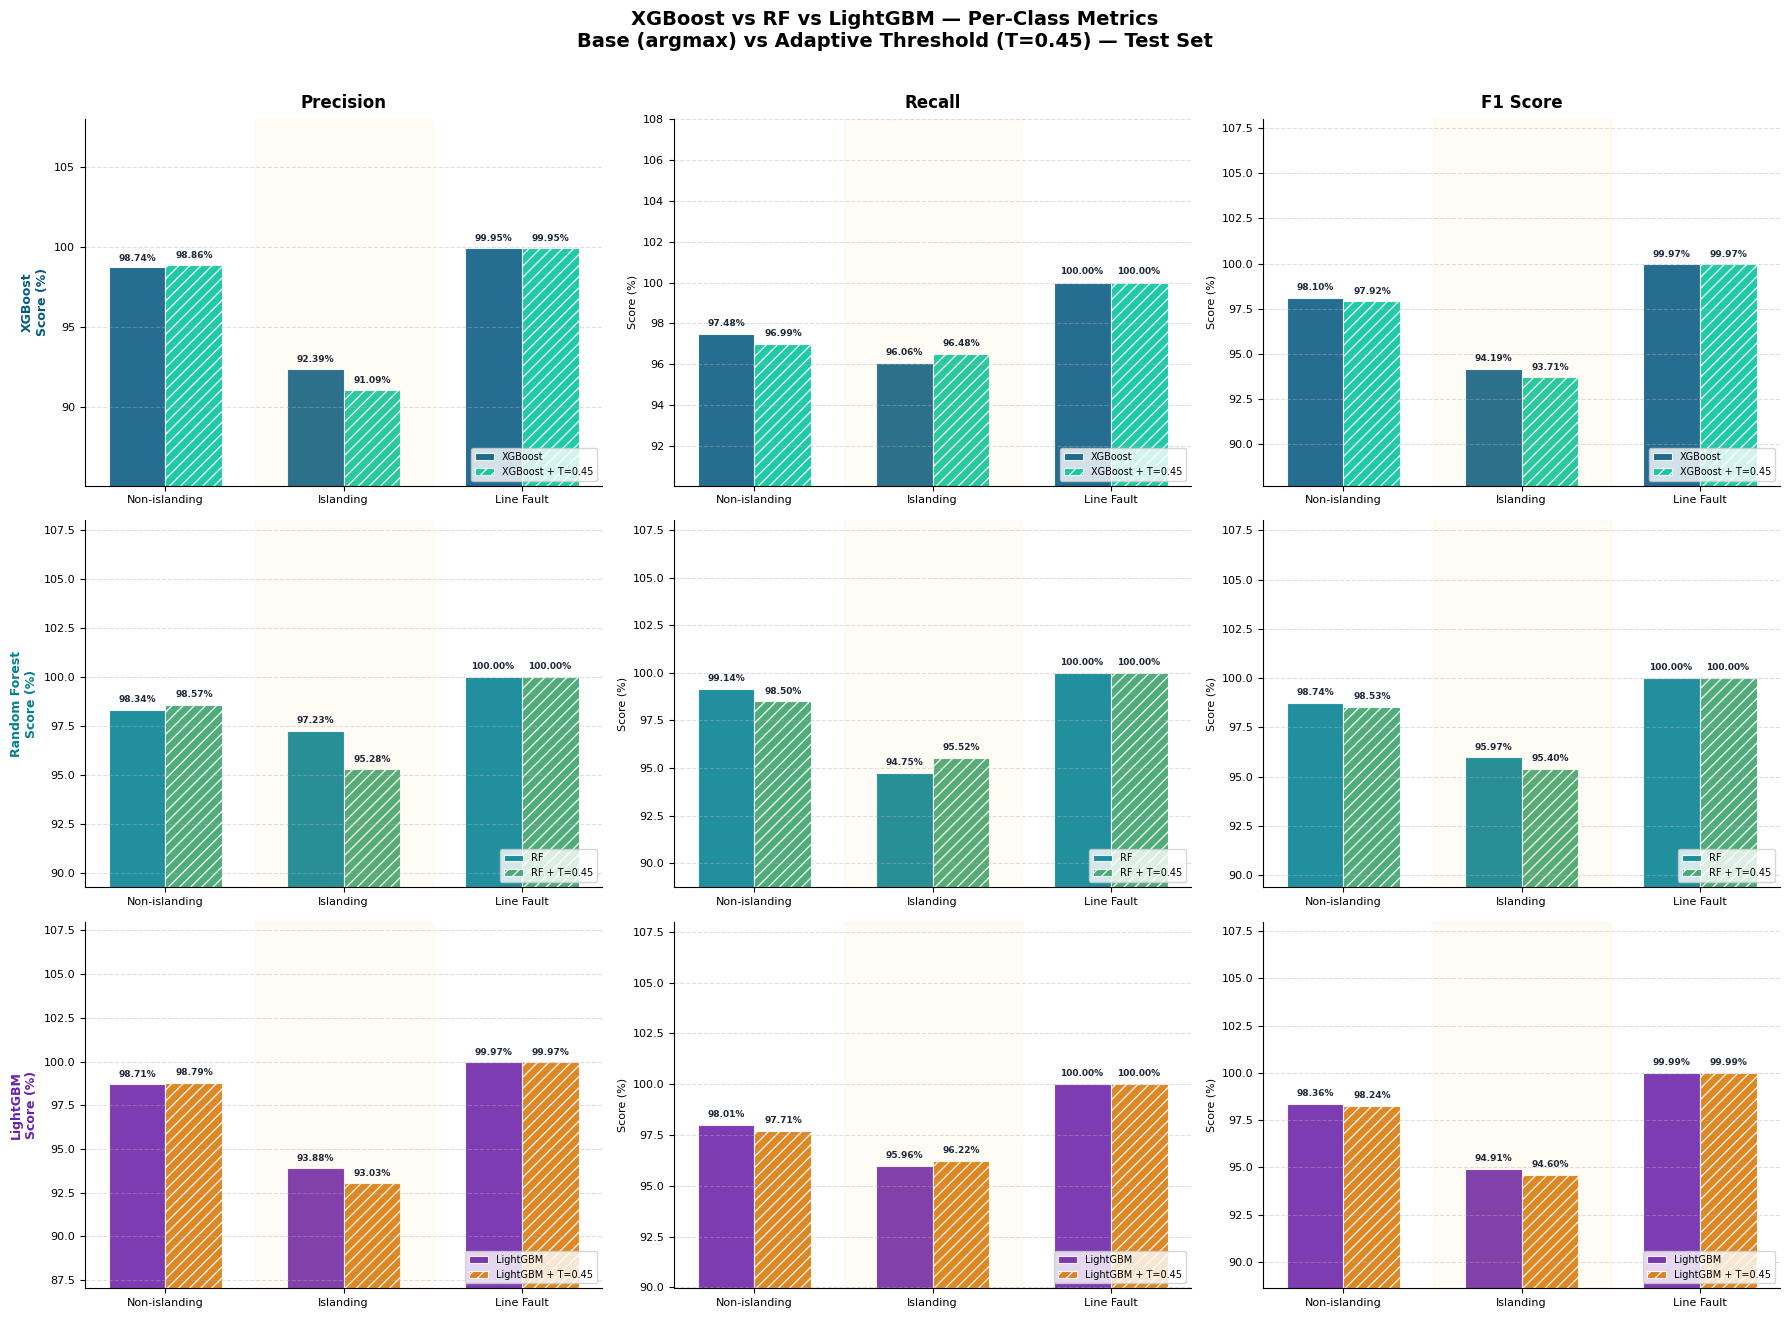

Figure 1 saved.


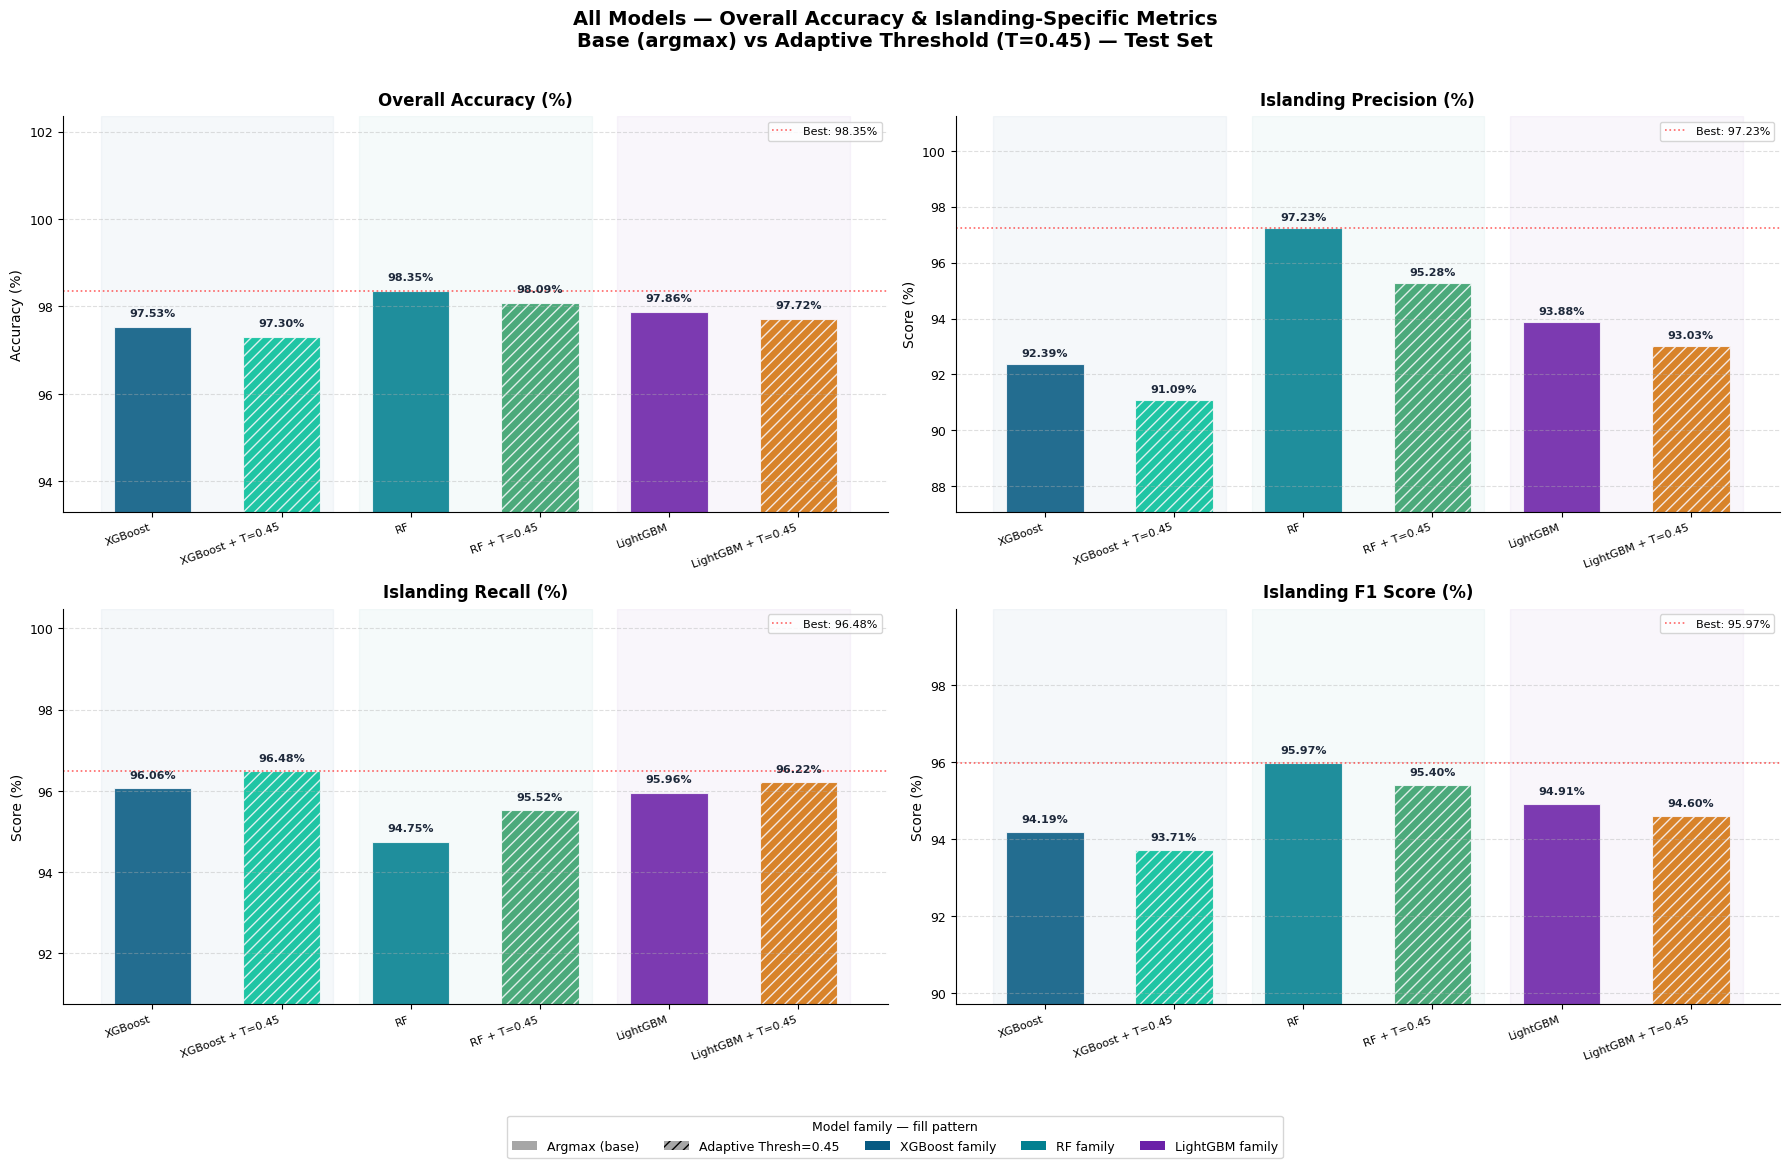

Figure 2 saved.

  FULL METRICS SUMMARY — TEST SET
  Model                       Accuracy   Isl_Rec   Isl_Pre    Isl_F1    MacroF1
  --------------------------------------------------------------------------
  XGBoost                       97.53%    96.06%    92.39%    94.19%
  XGBoost + T=0.45              97.30%    96.48%    91.09%    93.71% ★
  RF                            98.35%    94.75%    97.23%    95.97%
  RF + T=0.45                   98.09%    95.52%    95.28%    95.40%
  LightGBM                      97.86%    95.96%    93.88%    94.91%
  LightGBM + T=0.45             97.72%    96.22%    93.03%    94.60%

  ★ = highest islanding recall
  Hatched bars = Adaptive Threshold T=0.45 applied
Both figures saved to Figures/ folder.


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, accuracy_score)

CLASS_NAMES  = ["Non-islanding", "Islanding", "Line Fault"]
METRIC_NAMES = ["Precision", "Recall", "F1 Score"]

# ── Load all predictions ─────────────────────────────────────────
xgb_preds        = np.load(save_path + 'xgb_test_preds.npy')
xgb_thresh_preds = np.load(save_path + 'xgb_thresh_test_preds.npy')
rf_preds         = np.load(save_path + 'rf_test_preds.npy')
rf_thresh_preds  = np.load(save_path + 'rf_thresh_test_preds.npy')
lgb_preds        = np.load(save_path + 'lgb_test_preds.npy')
lgb_thresh_preds = np.load(save_path + 'lgb_thresh_test_preds.npy')

# ── Model groups — base + threshold pairs ────────────────────────
model_groups = [
    {
        "family":    "XGBoost",
        "base":      ("XGBoost",          xgb_preds),
        "thresh":    ("XGBoost + T=0.45", xgb_thresh_preds),
        "color_b":   "065A82",
        "color_t":   "02C39A",
    },
    {
        "family":    "Random Forest",
        "base":      ("RF",               rf_preds),
        "thresh":    ("RF + T=0.45",      rf_thresh_preds),
        "color_b":   "028090",
        "color_t":   "38A169",
    },
    {
        "family":    "LightGBM",
        "base":      ("LightGBM",         lgb_preds),
        "thresh":    ("LightGBM + T=0.45",lgb_thresh_preds),
        "color_b":   "6B21A8",
        "color_t":   "D97706",
    },
]

# ── Compute metrics ──────────────────────────────────────────────
def get_metrics(preds, y_true):
    prec = precision_score(y_true, preds, average=None,
                           zero_division=0, labels=[0,1,2]) * 100
    rec  = recall_score(y_true, preds, average=None,
                        zero_division=0, labels=[0,1,2]) * 100
    f1   = f1_score(y_true, preds, average=None,
                    zero_division=0, labels=[0,1,2]) * 100
    acc  = accuracy_score(y_true, preds) * 100
    return {"Precision": prec, "Recall": rec,
            "F1 Score": f1,   "Accuracy": acc}

for grp in model_groups:
    grp["base_metrics"]   = get_metrics(grp["base"][1],   y_test)
    grp["thresh_metrics"] = get_metrics(grp["thresh"][1], y_test)

# ── Verify predictions loaded correctly ──────────────────────────
print("Verification — Islanding Recall (test):")
for grp in model_groups:
    br = grp["base_metrics"]["Recall"][1]
    tr = grp["thresh_metrics"]["Recall"][1]
    print(f"  {grp['base'][0]:<22} {br:.2f}%   "
          f"{grp['thresh'][0]:<25} {tr:.2f}%")

# ════════════════════════════════════════════════════════════════
#  FIGURE 1 — Per-class metrics (Precision, Recall, F1)
#  One row per model family, one column per metric
# ════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(3, 3, figsize=(18, 13))
fig1.suptitle(
    "XGBoost vs RF vs LightGBM — Per-Class Metrics\n"
    "Base (argmax) vs Adaptive Threshold (T=0.45) — Test Set",
    fontsize=14, fontweight="bold", y=1.01
)

bar_width = 0.32
x = np.arange(len(CLASS_NAMES))

for row, grp in enumerate(model_groups):
    for col, metric in enumerate(METRIC_NAMES):

        ax = axes1[row, col]

        base_vals   = grp["base_metrics"][metric]
        thresh_vals = grp["thresh_metrics"][metric]

        # Find global min for y-axis
        y_min = max(0, min(min(base_vals), min(thresh_vals)) - 6)

        bars_b = ax.bar(x - bar_width/2, base_vals,
                        width=bar_width,
                        color="#" + grp["color_b"],
                        alpha=0.88, edgecolor="white",
                        linewidth=0.8,
                        label=grp["base"][0])
        bars_t = ax.bar(x + bar_width/2, thresh_vals,
                        width=bar_width,
                        color="#" + grp["color_t"],
                        alpha=0.88, edgecolor="white",
                        linewidth=0.8,
                        label=grp["thresh"][0],
                        hatch="///")

        # Value labels
        for bars, vals in [(bars_b, base_vals),
                           (bars_t, thresh_vals)]:
            for bar, val in zip(bars, vals):
                top = bar.get_height()
                if top < y_min + 6:
                    ly, va, fc = y_min + 1, "bottom", "white"
                else:
                    ly, va, fc = top + 0.3, "bottom", "#1E293B"
                ax.text(bar.get_x() + bar.get_width()/2,
                        ly, f"{val:.2f}%",
                        ha="center", va=va,
                        fontsize=6.5, fontweight="bold",
                        color=fc, rotation=0)

        # Islanding highlight
        ax.axvspan(0.5, 1.5, alpha=0.04, color="orange")

        # Row/col labels
        if col == 0:
            ax.set_ylabel(f"{grp['family']}\nScore (%)",
                          fontsize=9, fontweight="bold",
                          color="#" + grp["color_b"])
        else:
            ax.set_ylabel("Score (%)", fontsize=8)

        if row == 0:
            ax.set_title(metric, fontsize=12,
                         fontweight="bold", pad=8)

        ax.set_xticks(x)
        ax.set_xticklabels(CLASS_NAMES, fontsize=8,
                           rotation=0, ha="center")
        ax.set_ylim([y_min, 108])
        ax.yaxis.set_tick_params(labelsize=8)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.savefig(save_path + "Figures/classifier_perclass_metrics.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved.")

# ════════════════════════════════════════════════════════════════
#  FIGURE 2 — Overall Accuracy + Islanding-only summary
#  One grouped bar chart showing all 6 models side by side
# ════════════════════════════════════════════════════════════════
all_models = []
for grp in model_groups:
    all_models.append((grp["base"][0],   grp["base_metrics"],
                       "#" + grp["color_b"], "solid"))
    all_models.append((grp["thresh"][0], grp["thresh_metrics"],
                       "#" + grp["color_t"], "///"))

model_labels = [m[0] for m in all_models]
acc_vals     = [m[1]["Accuracy"]      for m in all_models]
isl_prec     = [m[1]["Precision"][1]  for m in all_models]
isl_rec      = [m[1]["Recall"][1]     for m in all_models]
isl_f1       = [m[1]["F1 Score"][1]   for m in all_models]
colors       = [m[2]                  for m in all_models]
hatches      = [m[3]                  for m in all_models]

x6 = np.arange(len(model_labels))

fig2, axes2 = plt.subplots(2, 2, figsize=(18, 11))
fig2.suptitle(
    "All Models — Overall Accuracy & Islanding-Specific Metrics\n"
    "Base (argmax) vs Adaptive Threshold (T=0.45) — Test Set",
    fontsize=14, fontweight="bold", y=1.01
)

panels = [
    (axes2[0,0], acc_vals,  "Overall Accuracy (%)",    "Accuracy (%)"),
    (axes2[0,1], isl_prec,  "Islanding Precision (%)", "Score (%)"),
    (axes2[1,0], isl_rec,   "Islanding Recall (%)",    "Score (%)"),
    (axes2[1,1], isl_f1,    "Islanding F1 Score (%)",  "Score (%)"),
]

for ax, vals, title, ylabel in panels:
    y_min = max(0, min(vals) - 4)

    for i, (val, col, hatch) in enumerate(
            zip(vals, colors, hatches)):
        bar = ax.bar(i, val, width=0.6,
                     color=col, alpha=0.88,
                     edgecolor="white", linewidth=0.8,
                     hatch=hatch if hatch != "solid" else "")

        top = bar[0].get_height()
        if top < y_min + 4:
            ly, va, fc = y_min + 0.5, "bottom", "white"
        else:
            ly, va, fc = top + 0.2, "bottom", "#1E293B"
        ax.text(i, ly, f"{val:.2f}%",
                ha="center", va=va,
                fontsize=8, fontweight="bold",
                color=fc, rotation=0)

    # Shade base vs threshold pairs
    for pair_start in [0, 2, 4]:
        ax.axvspan(pair_start - 0.4, pair_start + 1.4,
                   alpha=0.04,
                   color=colors[pair_start])

    ax.set_title(title, fontsize=12,
                 fontweight="bold", pad=8)
    ax.set_xticks(x6)
    ax.set_xticklabels(model_labels, fontsize=8,
                       rotation=20, ha="right")
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_ylim([y_min, max(vals) + 4])
    ax.yaxis.set_tick_params(labelsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Reference line at best value
    ax.axhline(y=max(vals), color="red",
               linestyle=":", linewidth=1.2,
               alpha=0.6, label=f"Best: {max(vals):.2f}%")
    ax.legend(fontsize=8)

# Legend for solid vs hatched
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="grey", alpha=0.7,
          label="Argmax (base)"),
    Patch(facecolor="grey", alpha=0.7,
          hatch="///", label="Adaptive Thresh=0.45"),
    Patch(facecolor="#065A82", label="XGBoost family"),
    Patch(facecolor="#028090", label="RF family"),
    Patch(facecolor="#6B21A8", label="LightGBM family"),
]
fig2.legend(handles=legend_elements,
            loc="lower center", ncol=5,
            fontsize=9, frameon=True,
            bbox_to_anchor=(0.5, -0.04),
            title="Model family — fill pattern",
            title_fontsize=9)

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig(save_path + "Figures/classifier_accuracy_islanding_summary.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

# ════════════════════════════════════════════════════════════════
#  FIGURE 3 — Summary table printed to console
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*82}")
print(f"  FULL METRICS SUMMARY — TEST SET")
print(f"{'='*82}")
print(f"  {'Model':<25} {'Accuracy':>10} {'Isl_Rec':>9} "
      f"{'Isl_Pre':>9} {'Isl_F1':>9} {'MacroF1':>10}")
print(f"  {'-'*74}")

best_rec = max(isl_rec)

for name, metrics, col, _ in all_models:
    acc    = metrics["Accuracy"]
    rec    = metrics["Recall"][1]
    pre    = metrics["Precision"][1]
    f1     = metrics["F1 Score"][1]
    mac_f1 = f1_score(y_test,
                      [m[1] for m in all_models
                       if m[0] == name][0],
                      average="macro",
                      zero_division=0) * 100 \
             if False else \
             np.mean([metrics["Precision"][i] *
                      metrics["Recall"][i] * 2 /
                      (metrics["Precision"][i] +
                       metrics["Recall"][i] + 1e-9)
                      for i in range(3)])
    star = " ★" if rec == best_rec else ""
    print(f"  {name:<25} {acc:>9.2f}% {rec:>8.2f}% "
          f"{pre:>8.2f}% {f1:>8.2f}%{star}")

print(f"\n  ★ = highest islanding recall")
print(f"  Hatched bars = Adaptive Threshold T=0.45 applied")
print("Both figures saved to Figures/ folder.")